In [1]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns

In [2]:
df = pd.read_csv("train_u6lujuX_CVtuZ9i.csv")
df.head()
df.shape

(614, 13)

In [3]:
print(df.info())

print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB
None
Loan_ID               0
Gender               13
Married               3
Dependents           15
Education  

In [4]:
df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
df['Married'].fillna(df['Married'].mode()[0], inplace=True)
df['Dependents'].fillna(df['Dependents'].mode()[0], inplace=True)
df['Self_Employed'].fillna(df['Self_Employed'].mode()[0], inplace=True)
df['Credit_History'].fillna(df['Credit_History'].mode()[0], inplace=True)
##use median for numerical values
df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)
df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].median(), inplace=True)
print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


C:\Users\lenovo\AppData\Local\Temp\ipykernel_14060\1497346896.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
C:\Users\lenovo\AppData\Local\Temp\ipykernel_14060\1497346896.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a cop

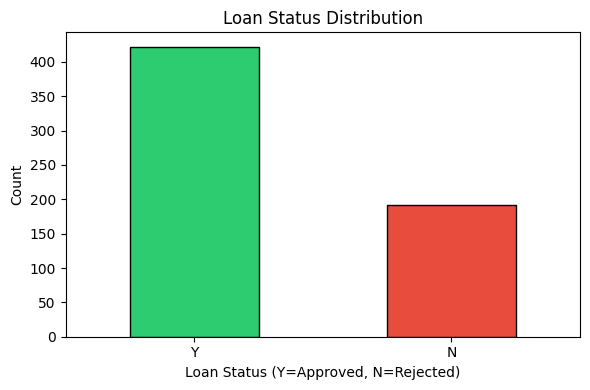

In [5]:
plt.figure(figsize=(6,4))
df['Loan_Status'].value_counts().plot(kind='bar', color=['#2ecc71', '#e74c3c'], edgecolor='black')
plt.title('Loan Status Distribution')
plt.xlabel('Loan Status (Y=Approved, N=Rejected)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

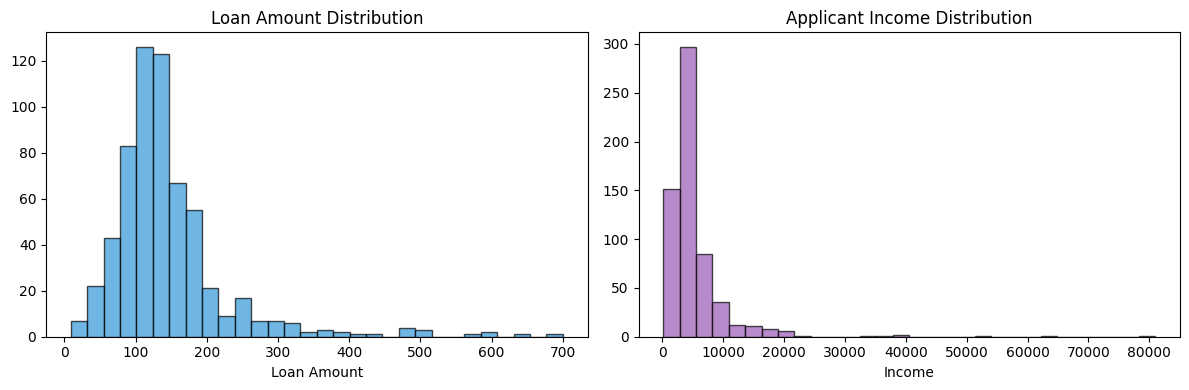

In [6]:
#Loan amount and income distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loan Amount
axes[0].hist(df['LoanAmount'], bins=30, color='#3498db', edgecolor='black', alpha=0.7)
axes[0].set_title('Loan Amount Distribution')
axes[0].set_xlabel('Loan Amount')

# Applicant Income
axes[1].hist(df['ApplicantIncome'], bins=30, color='#9b59b6', edgecolor='black', alpha=0.7)
axes[1].set_title('Applicant Income Distribution')
axes[1].set_xlabel('Income')

plt.tight_layout()
plt.show()

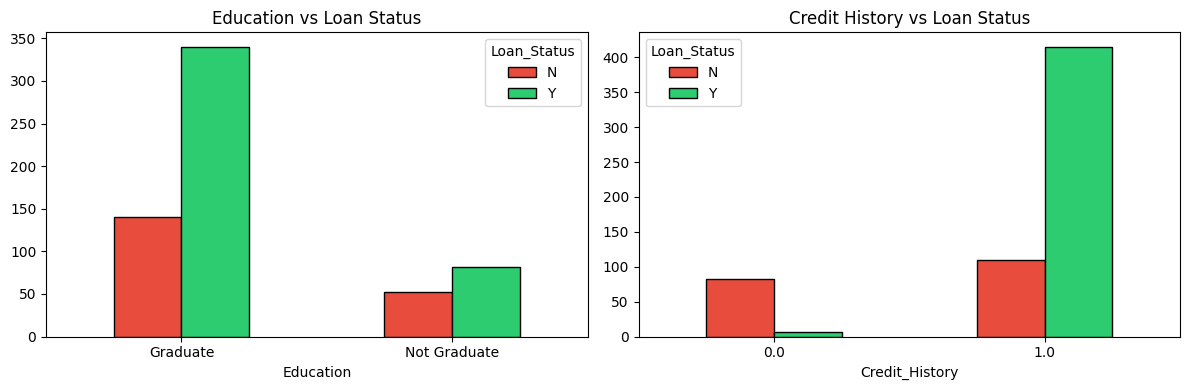

In [7]:
#Education and credit history VS loan status
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Education vs Loan Status
pd.crosstab(df['Education'], df['Loan_Status']).plot(kind='bar', ax=axes[0], 
            color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[0].set_title('Education vs Loan Status')
axes[0].tick_params(axis='x', rotation=0)

# Credit History vs Loan Status
pd.crosstab(df['Credit_History'], df['Loan_Status']).plot(kind='bar', ax=axes[1], 
            color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[1].set_title('Credit History vs Loan Status')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

In [8]:
#Label encoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder() 
cat_cols = ['Gender', 'Married', 'Dependents', 'Education', 
            'Self_Employed', 'Property_Area', 'Loan_Status']
for col in cat_cols:
    df[col]=le.fit_transform(df[col].astype(str))

print("encoding done")
df.head()    


encoding done


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,2,1
1,LP001003,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0
2,LP001005,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1
3,LP001006,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
4,LP001008,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1


In [9]:
df.drop('Loan_ID', axis=1, inplace=True)
print("✅ Loan_ID dropped!")
df.head()

✅ Loan_ID dropped!


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,2,1
1,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0
2,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1
3,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
4,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1


In [10]:
#split data into train and test
from sklearn.model_selection import train_test_split

X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)
print(" Data split done!")

Train size: (491, 11)
Test size: (123, 11)
 Data split done!


In [11]:
#train logistic regression model
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

lr_preds = lr.predict(X_test)

print(" Logistic Regression trained!")

 Logistic Regression trained!


c:\Users\lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [12]:
#train decision tree model
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)

dt_preds = dt.predict(X_test)

print(" Decision Tree trained!")

 Decision Tree trained!


In [13]:
#accuracy and confusion matrix
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Accuracy
lr_acc = accuracy_score(y_test, lr_preds)
dt_acc = accuracy_score(y_test, dt_preds)

print(f"Logistic Regression Accuracy: {lr_acc*100:.2f}%")
print(f"Decision Tree Accuracy:       {dt_acc*100:.2f}%")

Logistic Regression Accuracy: 78.86%
Decision Tree Accuracy:       74.80%


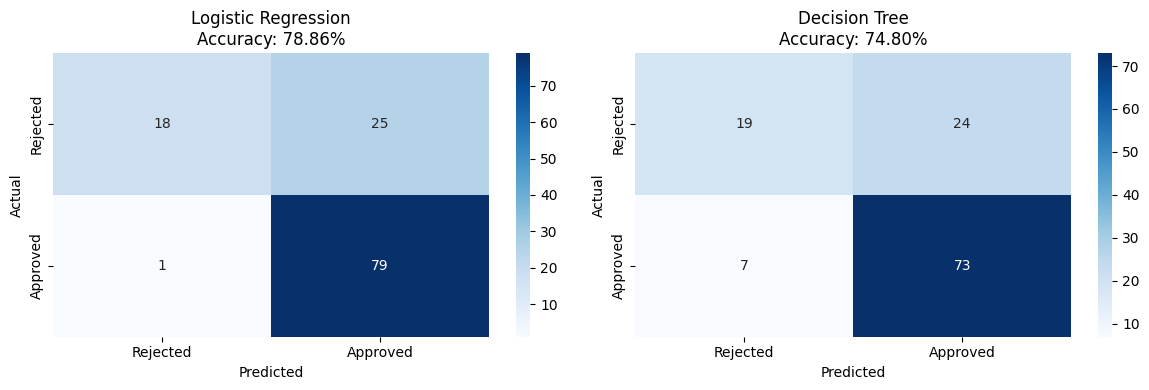

In [14]:
#visualize confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (name, preds) in zip(axes, [('Logistic Regression', lr_preds),
                                      ('Decision Tree', dt_preds)]):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Rejected', 'Approved'],
                yticklabels=['Rejected', 'Approved'])
    acc = accuracy_score(y_test, preds)
    ax.set_title(f'{name}\nAccuracy: {acc*100:.2f}%')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [15]:
#classification report
print("=" * 50)
print("LOGISTIC REGRESSION — Classification Report")
print("=" * 50)
print(classification_report(y_test, lr_preds, target_names=['Rejected', 'Approved']))

print("=" * 50)
print("DECISION TREE — Classification Report")
print("=" * 50)
print(classification_report(y_test, dt_preds, target_names=['Rejected', 'Approved']))

LOGISTIC REGRESSION — Classification Report
              precision    recall  f1-score   support

    Rejected       0.95      0.42      0.58        43
    Approved       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123

DECISION TREE — Classification Report
              precision    recall  f1-score   support

    Rejected       0.73      0.44      0.55        43
    Approved       0.75      0.91      0.82        80

    accuracy                           0.75       123
   macro avg       0.74      0.68      0.69       123
weighted avg       0.74      0.75      0.73       123

